In [37]:
import string
import numpy as np
from PIL import Image
import os
from pickle import dump, load
import numpy as np


from keras.preprocessing.image import load_img, img_to_array
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical
from tensorflow.keras.layers import add
from keras.models import Model, load_model
from keras.layers import Input, Dense, LSTM, Embedding, Dropout
from transformers import ViTFeatureExtractor, ViTModel
import torch

# small library for seeing the progress of loops.
from tqdm.notebook import tqdm
# tqdm().pandas()

## Flickr - 8 k Data set

In [ ]:
dataset_text = "dataset/Flickr8k_text"
dataset_images = "dataset/Flicker8k_Dataset"

## Preparing the data

In [ ]:
def load_doc(filename):
    file = open(filename, 'r')
    text = file.read()
    file.close()
    return text

def all_img_captions(filename):
    file = load_doc(filename)
    captions = file.split('\n')
    descriptions = {}
    for caption in captions[:-1]:
        img, caption = caption.split('\t')
        if img[:-2] not in descriptions:
            descriptions[img[:-2]] = [caption]
        else:
            descriptions[img[:-2]].append(caption)
    return descriptions

def cleaning_text(captions):
    table = str.maketrans('', '', string.punctuation)
    for img, caps in captions.items():
        for i, img_caption in enumerate(caps):
            img_caption.replace("-", " ")
            desc = img_caption.split()
            desc = [word.lower() for word in desc]
            desc = [word.translate(table) for word in desc]
            desc = [word for word in desc if len(word) > 1]
            desc = [word for word in desc if word.isalpha()]
            img_caption = ' '.join(desc)
            captions[img][i] = img_caption
    return captions

def text_vocabulary(descriptions):
    vocab = set()
    for key in descriptions.keys():
        [vocab.update(d.split()) for d in descriptions[key]]
    return vocab

def save_descriptions(descriptions, filename):
    lines = list()
    for key, desc_list in descriptions.items():
        for desc in desc_list:
            lines.append(key + '\t' + desc)
    data = "\n".join(lines)
    file = open(filename, "w")
    file.write(data)
    file.close()


In [ ]:
filename = dataset_text + "/" + "Flickr8k.token.txt"
descriptions = all_img_captions(filename)
print("Length of descriptions =", len(descriptions))

clean_descriptions = cleaning_text(descriptions)

vocabulary = text_vocabulary(clean_descriptions)
print("Length of vocabulary =", len(vocabulary))

save_descriptions(clean_descriptions, "descriptions.txt")


Length of descriptions = 8092
Length of vocabulary =  8763


## Feature Extraction using Vit Encoder

In [ ]:
feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")
vit_model = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")

def extract_features_vit(directory):
    features = {}
    for img_name in tqdm(os.listdir(directory)):
        path = os.path.join(directory, img_name)
        image = Image.open(path).convert("RGB")
        inputs = feature_extractor(images=image, return_tensors="pt")
        with torch.no_grad():
            outputs = vit_model(**inputs)
        pooled_features = outputs.last_hidden_state.mean(dim=1).squeeze().numpy()
        features[img_name] = pooled_features
    return features


In [ ]:
## dont run everytime
#768 feature vector for ViT
features = extract_features_vit(dataset_images)
dump(features, open("features.p","wb"))

In [ ]:
def load_photos(filename):
    file = load_doc(filename)
    photos = file.split("\n")[:-1]
    return photos

def load_clean_descriptions(filename, photos):
    file = load_doc(filename)
    descriptions = {}
    for line in file.split("\n"):
        words = line.split()
        if len(words) < 1:
            continue
        image, image_caption = words[0], words[1:]
        if image in photos:
            if image not in descriptions:
                descriptions[image] = []
            desc = '<start> ' + " ".join(image_caption) + ' <end>'
            descriptions[image].append(desc)
    return descriptions

def load_features(photos):
    all_features = load(open("features.p", "rb"))
    features = {k: all_features[k] for k in photos}
    return features

filename = dataset_text + "/" + "Flickr_8k.trainImages.txt"
train_imgs = load_photos(filename)
train_descriptions = load_clean_descriptions("descriptions.txt", train_imgs)
train_features = load_features(train_imgs)


In [ ]:
def dict_to_list(descriptions):
    all_desc = []
    for key in descriptions.keys():
        [all_desc.append(d) for d in descriptions[key]]
    return all_desc

def create_tokenizer(descriptions):
    desc_list = dict_to_list(descriptions)
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(desc_list)
    return tokenizer


In [ ]:
tokenizer = create_tokenizer(train_descriptions)
dump(tokenizer, open('tokenizer.p', 'wb'))
vocab_size = len(tokenizer.word_index) + 1
vocab_size


7577

In [45]:
#calculate maximum length of descriptions
def max_length(descriptions):
    desc_list = dict_to_list(descriptions)
    return max(len(d.split()) for d in desc_list)
    
max_length = max_length(descriptions)
max_length

32

### Data Generator

In [ ]:


from keras.utils import to_categorical
import numpy as np

# Load extracted ViT features
features = load(open("features.p", "rb"))

# Create sequences for training
def create_sequences(tokenizer, max_length, descriptions, photos, vocab_size):
    X1, X2, y = [], [], []

    for key, desc_list in descriptions.items():
        if key not in photos:
            continue
        for desc in desc_list:
            seq = tokenizer.texts_to_sequences([desc])[0]
            for i in range(1, len(seq)):
                in_seq, out_seq = seq[:i], seq[i]
                in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]

                X1.append(photos[key])
                X2.append(in_seq)
                y.append(out_seq)
    
    return np.array(X1), np.array(X2), np.array(y)

In [ ]:
from torch.utils.data import DataLoader
import torch
from transformers import GPT2Tokenizer, ViTFeatureExtractor
from PIL import Image
import os

class Flickr8kCaptionDataset(torch.utils.data.Dataset):
    def __init__(self, image_folder, captions_file, tokenizer_name='gpt2', max_length=32):
        self.image_folder = image_folder
        self.max_length = max_length
        self.tokenizer = GPT2Tokenizer.from_pretrained(tokenizer_name)
        self.tokenizer.pad_token = self.tokenizer.eos_token
        self.feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")

        self.image_paths = []
        self.captions = []

        with open(captions_file, 'r') as file:
            for line in file:
                parts = line.strip().split('\t')
                if len(parts) == 2:
                    raw_name, caption = parts
                    image_name = raw_name.split('#')[0]
                    image_name = image_name.split('.')[0] + '.jpg'
                    full_path = os.path.join(self.image_folder, image_name)
                    if os.path.exists(full_path):
                        self.image_paths.append(image_name)
                        self.captions.append(caption)

    def __len__(self):
        return len(self.captions)

    def __getitem__(self, idx):
        image_path = os.path.join(self.image_folder, self.image_paths[idx])
        image = Image.open(image_path).convert("RGB")
        image_tensor = self.feature_extractor(images=image, return_tensors="pt")["pixel_values"].squeeze(0)

        encoding = self.tokenizer(self.captions[idx],
                                  return_tensors="pt",
                                  padding="max_length",
                                  truncation=True,
                                  max_length=self.max_length)
        input_ids = encoding["input_ids"].squeeze(0)

        return {
            "image": image_tensor,
            "input_ids": input_ids
        }

def collate_fn(batch):
    images = torch.stack([item['image'] for item in batch])
    input_ids = [item['input_ids'] for item in batch]

    input_ids_padded = torch.nn.utils.rnn.pad_sequence(
        input_ids, batch_first=True, padding_value=50256
    )

    return {
        'image': images,
        'input_ids': input_ids_padded
    }

dataset = Flickr8kCaptionDataset(
    image_folder="dataset/Flicker8k_Dataset",
    captions_file="descriptions.txt"
)

dataloader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_fn
)


### Image Captioning Model 

In [ ]:
def define_model(vocab_size, max_length):
    inputs1 = Input(shape=(768,))
    fe1 = Dropout(0.5)(inputs1)
    fe2 = Dense(256, activation='relu')(fe1)

    inputs2 = Input(shape=(max_length,))
    se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
    se2 = Dropout(0.5)(se1)
    se3 = LSTM(256)(se2)

    decoder1 = add([fe2, se3])
    decoder2 = Dense(256, activation='relu')(decoder1)
    outputs = Dense(vocab_size, activation='softmax')(decoder2)

    model = Model(inputs=[inputs1, inputs2], outputs=outputs)
    model.compile(loss='categorical_crossentropy', optimizer='adam')
    return model

model = define_model(vocab_size, max_length)
model.summary()



In [ ]:
import torch
import torch.nn as nn
from transformers import GPT2Tokenizer, GPT2LMHeadModel, ViTModel

class ImageCaptioningGPT2(nn.Module):
    def __init__(self, gpt2_model_name='gpt2', vit_model_name='google/vit-base-patch16-224-in21k', prefix_len=10):
        super(ImageCaptioningGPT2, self).__init__()
        self.prefix_len = prefix_len

        self.vit = ViTModel.from_pretrained(vit_model_name)
        self.gpt2 = GPT2LMHeadModel.from_pretrained(gpt2_model_name)
        self.tokenizer = GPT2Tokenizer.from_pretrained(gpt2_model_name)

        for param in self.vit.parameters():
            param.requires_grad = False
        for param in self.gpt2.parameters():
            param.requires_grad = False

        self.prefix_projector = nn.Sequential(
            nn.Linear(self.vit.config.hidden_size, self.gpt2.config.n_embd * prefix_len),
            nn.Tanh()
        )

    def forward(self, images, input_ids, labels=None):
        with torch.no_grad():
            vit_outputs = self.vit(pixel_values=images)
            vit_cls = vit_outputs.last_hidden_state[:, 0]

        prefix_embeddings = self.prefix_projector(vit_cls)
        prefix_embeddings = prefix_embeddings.view(-1, self.prefix_len, self.gpt2.config.n_embd)

        gpt2_inputs = self.gpt2.transformer.wte(input_ids)
        full_input = torch.cat((prefix_embeddings, gpt2_inputs), dim=1)

        if labels is not None:
            prefix_padding = torch.full((labels.size(0), self.prefix_len), -100, dtype=torch.long, device=labels.device)
            labels = torch.cat((prefix_padding, labels), dim=1)

        outputs = self.gpt2(inputs_embeds=full_input, labels=labels, return_dict=True)
        return outputs

    def generate(self, image, max_length=30):
        with torch.no_grad():
            vit_outputs = self.vit(pixel_values=image)
            vit_cls = vit_outputs.last_hidden_state[:, 0]

        prefix_embeddings = self.prefix_projector(vit_cls).view(1, self.prefix_len, self.gpt2.config.n_embd)
        generated = torch.tensor([[self.tokenizer.bos_token_id]], dtype=torch.long, device=prefix_embeddings.device)

        for _ in range(max_length):
            gpt2_inputs = self.gpt2.transformer.wte(generated)
            full_input = torch.cat((prefix_embeddings, gpt2_inputs), dim=1)
            outputs = self.gpt2(inputs_embeds=full_input)
            next_token_logits = outputs.logits[:, -1, :]
            next_token = torch.argmax(next_token_logits, dim=-1, keepdim=True)
            generated = torch.cat((generated, next_token), dim=1)
            if next_token.item() == self.tokenizer.eos_token_id:
                break

        caption = self.tokenizer.decode(generated.squeeze(), skip_special_tokens=True)
        return caption.strip()


### Training

In [ ]:
print('Dataset: ', len(train_imgs))
print('Descriptions: train=', len(train_descriptions))
print('Photos: train=', len(train_features))
print('Vocabulary Size:', vocab_size)
print('Description Length: ', max_length)

from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch.nn.functional as F

def train(model, dataloader, optimizer, device, epochs=10, save_path="vit_gpt_model.pth", patience=3):
    model.train()
    model.to(device)

    best_loss = float("inf")
    epochs_without_improvement = 0

    for epoch in range(epochs):
        total_loss = 0.0
        model.train()
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")

        for batch in pbar:
            images = batch["image"].to(device)
            input_ids = batch["input_ids"].to(device)
            labels = input_ids.clone()

            optimizer.zero_grad()
            outputs = model(images, input_ids=input_ids, labels=labels)
            loss = outputs.loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pbar.set_postfix(loss=total_loss / (pbar.n + 1))

        epoch_loss = total_loss / len(dataloader)
        print(f"✅ Epoch {epoch+1} complete. Avg Loss: {epoch_loss:.4f}")

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            epochs_without_improvement = 0
            torch.save(model.state_dict(), save_path)
            print(f"📦 Best model saved (loss: {best_loss:.4f})")
        else:
            epochs_without_improvement += 1
            print(f"📉 No improvement for {epochs_without_improvement} epoch(s).")

        if epochs_without_improvement >= patience:
            print("⏹️ Early stopping triggered.")
            break


Dataset:  6000
Descriptions: train= 6000
Photos: train= 6000
Vocabulary Size: 7577
Description Length:  32


In [ ]:
dataset = Flickr8kCaptionDataset("dataset/Flicker8k_Dataset", "descriptions.txt")
dataloader = DataLoader(dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = ImageCaptioningGPT2()
optimizer = torch.optim.Adam(model.prefix_projector.parameters(), lr=1e-4)

train(model, dataloader, optimizer, device, epochs=10, save_path="vit_gpt_model.pth")




Caption:  17. I was going to a party.

18. I was going to a party.

19. I was going to


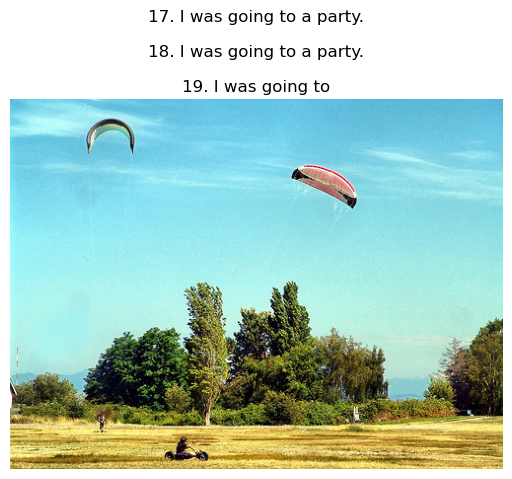

In [ ]:
from PIL import Image
from transformers import ViTFeatureExtractor
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")

def top_k_top_p_filtering(logits, top_k=0, top_p=1.0, filter_value=-float('Inf')):
    top_k = min(top_k, logits.size(-1))
    if top_k > 0:
        top_k_values = torch.topk(logits, top_k)[0][..., -1, None]
        logits = logits.masked_fill(logits < top_k_values, filter_value)

    if top_p < 1.0:
        sorted_logits, sorted_indices = torch.sort(logits, descending=True, dim=-1)
        cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
        sorted_mask = cumulative_probs > top_p
        sorted_mask[..., 1:] = sorted_mask[..., :-1].clone()
        sorted_mask[..., 0] = 0
        for i in range(logits.size(0)):
            indices_to_remove = sorted_indices[i][sorted_mask[i]]
            logits[i].scatter_(0, indices_to_remove, filter_value)

    return logits

def generate_caption(model, image_path, device, max_length=30, temperature=1.0, top_k=50, top_p=0.9):
    model.eval()
    model.to(device)

    image = Image.open(image_path).convert("RGB")
    inputs = feature_extractor(images=image, return_tensors="pt")
    image_tensor = inputs["pixel_values"].to(device)

    with torch.no_grad():
        vit_outputs = model.vit(pixel_values=image_tensor)
        vit_cls = vit_outputs.last_hidden_state[:, 0]
        prefix_embeddings = model.prefix_projector(vit_cls).view(1, model.prefix_len, model.gpt2.config.n_embd)
        generated = torch.tensor(model.tokenizer.encode(""), dtype=torch.long).unsqueeze(0).to(device)

        for _ in range(max_length):
            gpt2_inputs = model.gpt2.transformer.wte(generated)
            full_input = torch.cat((prefix_embeddings, gpt2_inputs), dim=1)
            outputs = model.gpt2(inputs_embeds=full_input)
            logits = outputs.logits[:, -1, :] / temperature
            filtered_logits = top_k_top_p_filtering(logits, top_k=top_k, top_p=top_p)
            probs = F.softmax(filtered_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            generated = torch.cat((generated, next_token), dim=1)
            if next_token.item() == model.tokenizer.eos_token_id:
                break

        caption = model.tokenizer.decode(generated.squeeze(), skip_special_tokens=True)
        return caption.strip()

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

def display_image_with_caption(image_path, caption):
    img = Image.open(image_path)
    print("Caption: ", caption)
    plt.imshow(img)
    plt.axis("off")
    plt.title(caption)
    plt.show()

image_path = "dataset/Flicker8k_Dataset/3726019124_f302b3d48a.jpg" 
caption = generate_caption(model, image_path, device)
display_image_with_caption(image_path, caption)


### Testing 

In [ ]:
import torch
from tqdm import tqdm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score

def generate_caption_from_image(model, image_tensor, device, max_length=30):
    model.eval()
    image_tensor = image_tensor.to(device)
    with torch.no_grad():
        caption = model.generate(image_tensor, max_length=max_length)
    return caption.strip()

def evaluate_model(model, dataloader, references_dict, device, max_length=30):
    smooth = SmoothingFunction().method4
    scores = []

    for batch in tqdm(dataloader, desc="Evaluating"):
        images = batch["image"].to(device)
        image_names = batch["name"]

        for i in range(len(images)):
            img_tensor = images[i].unsqueeze(0)  # Shape: (1, 3, 224, 224)
            img_name = image_names[i]

            if img_name not in references_dict:
                continue

            predicted_caption = generate_caption_from_image(model, img_tensor, device, max_length)
            references = [ref.split() for ref in references_dict[img_name]]
            candidate = predicted_caption.split()

            bleu1 = sentence_bleu(references, candidate, weights=(1.0, 0, 0, 0), smoothing_function=smooth)
            bleu2 = sentence_bleu(references, candidate, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth)
            bleu3 = sentence_bleu(references, candidate, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smooth)
            bleu4 = sentence_bleu(references, candidate, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth)
            meteor = meteor_score(references, candidate)

            scores.append({
                "image": img_name,
                "predicted": predicted_caption,
                "bleu1": bleu1,
                "bleu2": bleu2,
                "bleu3": bleu3,
                "bleu4": bleu4,
                "meteor": meteor
            })

    return scores

results = evaluate_model(model, dataloader, train_descriptions, device, max_length=30)

In [ ]:
def display_image(image_path):
    img = Image.open(image_path)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

Average BLEU-1: 0.4638
Average BLEU-2: 0.2847
Average BLEU-3: 0.1827
Average BLEU-4: 0.1189
Average METEOR: 0.2744



 Bottom 5 Captions by BLEU-4:

Image: 1386964743_9e80d96b05.jpg
Caption: two people are walking down hill
BLEU-4: 0.0000


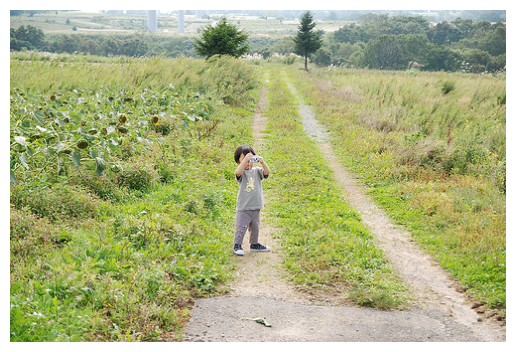

Image: 2061354254_faa5bd294b.jpg
Caption: two boys are playing in the air with kite ribbons
BLEU-4: 0.0000


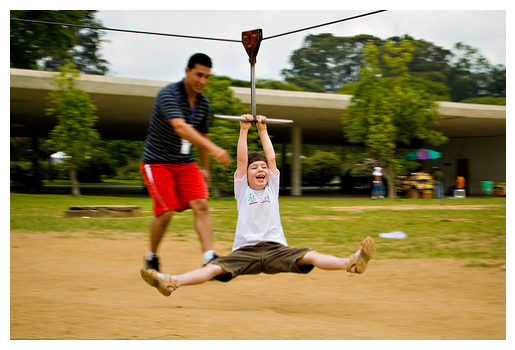

Image: 2431832075_00aa1a4457.jpg
Caption: two children are practicing takedown fire
BLEU-4: 0.0000


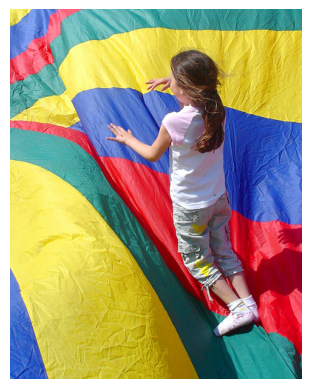

Image: 3186412658_2ab2ebd397.jpg
Caption: two men in red soccer uniforms are playing soccer
BLEU-4: 0.0000


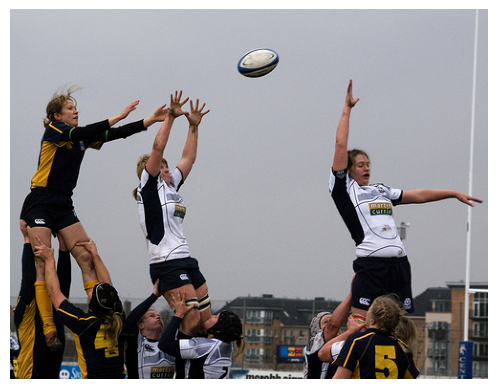

Image: 2247889670_413db8094b.jpg
Caption: child pulls her ice fishing
BLEU-4: 0.0137


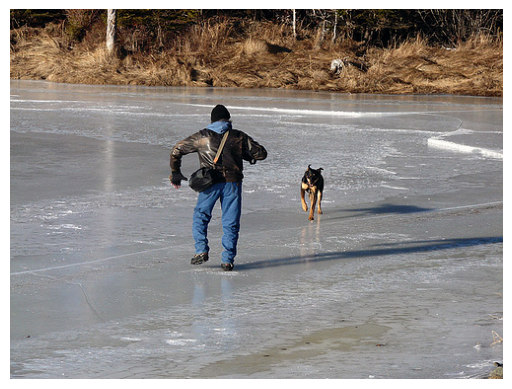

In [ ]:
def summarize_scores(results):
    bleu1_scores = [r[2] for r in results]
    bleu2_scores = [r[3] for r in results]
    bleu3_scores = [r[4] for r in results]
    bleu4_scores = [r[5] for r in results]
    meteor_scores = [r[6] for r in results]

    print("Average BLEU-1: {:.4f}".format(np.mean(bleu1_scores)))
    print("Average BLEU-2: {:.4f}".format(np.mean(bleu2_scores)))
    print("Average BLEU-3: {:.4f}".format(np.mean(bleu3_scores)))
    print("Average BLEU-4: {:.4f}".format(np.mean(bleu4_scores)))
    print("Average METEOR: {:.4f}".format(np.mean(meteor_scores)))



summarize_scores(results)
print("\n")

image_dir = "dataset/Flicker8k_Dataset/"
# Top 5 by BLEU-4
sorted_by_bleu4 = sorted(results, key=lambda x: x[5], reverse=True)
print(" Top 5 Captions by BLEU-4:\n")
for r in sorted_by_bleu4[:5]:
    print(f"Image: {r[0]}")
    print(f"Caption: {r[1]}")
    print(f"BLEU-4: {r[5]:.4f}")
    display_image(os.path.join(image_dir, r[0]))


# Bottom 5 by METEOR

print("\n Bottom 5 Captions by BLEU-4:\n")
sorted_by_bleu4 = sorted(results, key=lambda x: x[5])
for r in sorted_by_bleu4[:5]:
    print(f"Image: {r[0]}")
    print(f"Caption: {r[1]}")
    print(f"BLEU-4: {r[5]:.4f}")
    display_image(os.path.join(image_dir, r[0]))









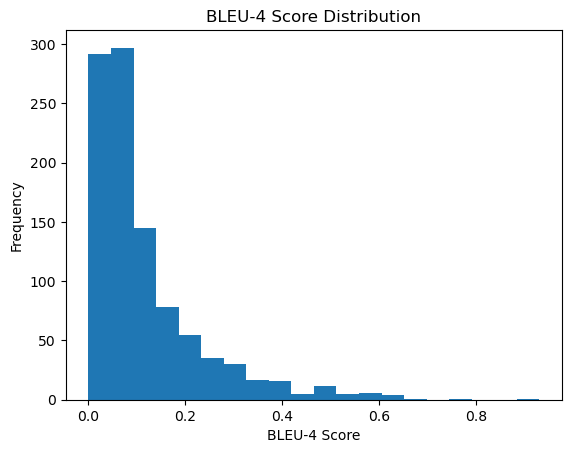

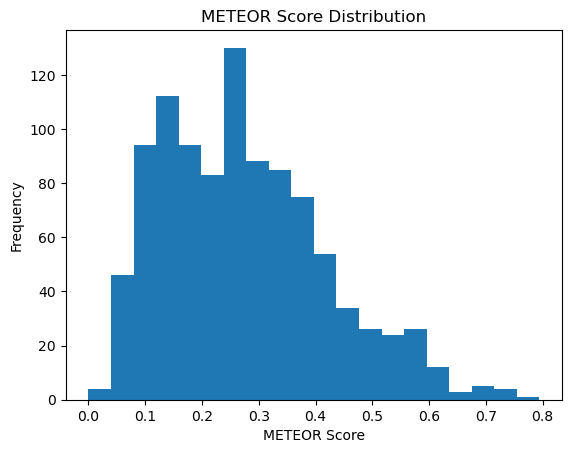

In [ ]:
import matplotlib.pyplot as plt

bleu4 = [r[5] for r in results]
meteor = [r[6] for r in results]

plt.hist(bleu4, bins=20)
plt.title("BLEU-4 Score Distribution")
plt.xlabel("BLEU-4 Score")
plt.ylabel("Frequency")
plt.show()

plt.hist(meteor, bins=20)
plt.title("METEOR Score Distribution")
plt.xlabel("METEOR Score")
plt.ylabel("Frequency")
plt.show()
